**Few things I tried during Session:**
1.like for the best optimal policy we set reward_schedule(100,-50,-1) simply will reach goal . and if  instead of -ve reward for every state if we do the +ve then it will not reach goal and will roam in the map as its +ve reward is inc

2.I tried with reducing the epsilon gamma to make it greedy and reward_schedule=(10,-1,-1) its visible that being greedy if its negative reward will grow more then that +10 would not mattter it will fall in hole ...output is in image

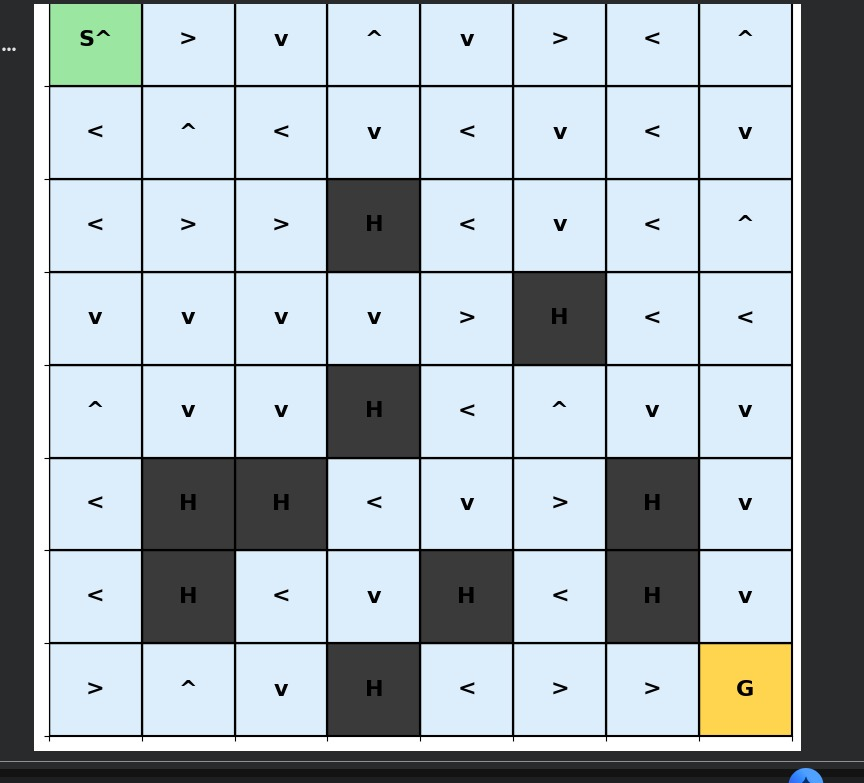


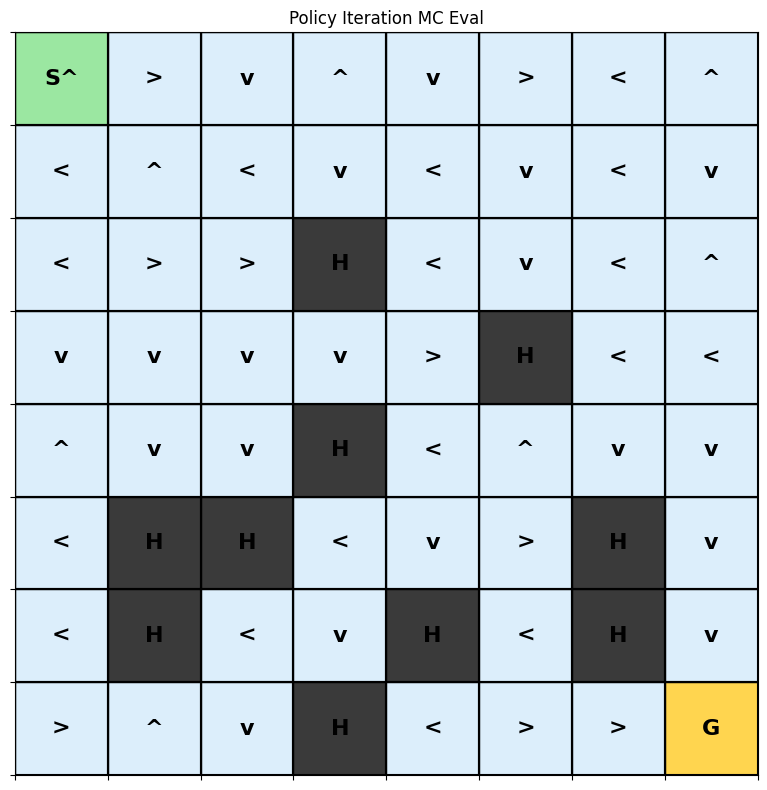

In [46]:
from __future__ import annotations

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

def build_env(map_name: str = "8x8", slippery: bool = False):
    return gym.make(
        "FrozenLake-v1",
        map_name=map_name,
        is_slippery=slippery,
        reward_schedule=(10,-1,-1)
    )

def extract_model(env: gym.Env):
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    transition = np.zeros((n_states, n_actions, n_states), dtype=float)
    reward = np.zeros((n_states, n_actions, n_states), dtype=float)

    for state in range(n_states):
        for action in range(n_actions):
            for prob, next_state, r, _terminated in env.unwrapped.P[state][action]:
                transition[state, action, next_state] += prob
                reward[state, action, next_state] = r

    expected_reward = np.sum(transition * reward, axis=2)
    return transition, reward, expected_reward

def policy_eval_mc(env, policy, gamma, episode=5000):

    n_states = env.observation_space.n
    n_actions = env.action_space.n
    q_values = np.zeros((n_states, n_actions))
    return_counts = np.zeros((n_states, n_actions))

    for ep in range(episode):
        env.reset()

        #keeping the state and action random as to cover max
        #earlier i was starting with fixed state which was not giving good result so implemented the Exploration Start MC-Es
        state = np.random.randint(n_states)
        action = np.random.randint(n_actions)
        env.unwrapped.s = state

        #for saving the path which we follow for the episode
        episodes = []
        while True:
            next_state, reward, terminated, truncated, _ = env.step(action)
            episodes.append((state, action, reward))

            if terminated or truncated:
                break
            state = next_state
            action = policy[state]

        G = 0
        visited=set()
        #evalutating it from reverse
        for s,action,r in reversed(episodes):
          G =gamma*G+r
          if(s,action) not in visited:
            visited.add((s,action))
            return_counts[s,action] += 1
            q_values[s,action] += (G-q_values[s,action])/return_counts[s,action]
    return q_values

def policy_iteration(env, transition, expected_reward, gamma=0.99, max_iterations=1000):
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    #making a random policy
    policy = np.random.choice(n_actions, size=n_states)

    for iteration in range(max_iterations):
        q_values = policy_eval_mc(env, policy, gamma, episode=5000)
        new_policy = np.argmax(q_values, axis=1)

        if np.array_equal(new_policy, policy):
            values = np.max(q_values, axis=1)
            return values, policy, iteration + 1

        policy = new_policy

    values = np.max(q_values, axis=1)
    return values, policy, max_iterations

def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
    desc = np.asarray(env.unwrapped.desc, dtype=str)
    policy_grid = np.asarray(policy).reshape(desc.shape)
    arrows = np.array(["<", "v", ">", "^"])
    colors = {
        "S": "#9be7a1",
        "F": "#dceefb",
        "H": "#3a3a3a",
        "G": "#ffd54f",
    }

    fig, ax = plt.subplots(figsize=(8, 8))
    for r in range(desc.shape[0]):
        for c in range(desc.shape[1]):
            tile = desc[r, c]
            rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
            ax.add_patch(rect)

            if tile == "H":
                label = "H"
            elif tile == "G":
                label = "G"
            elif tile == "S":
                label = f"S{arrows[policy_grid[r, c]]}"
            else:
                label = arrows[policy_grid[r, c]]

            ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")

    ax.set_xlim(0, desc.shape[1])
    ax.set_ylim(0, desc.shape[0])
    ax.set_xticks(np.arange(desc.shape[1] + 1))
    ax.set_yticks(np.arange(desc.shape[0] + 1))
    ax.grid(True, color="black", linewidth=1.0)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_aspect("equal")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def main():
    gamma = 0.1
    env = build_env(slippery=False)
    transition, reward, expected_reward = extract_model(env)

    _, pi_policy, _ = policy_iteration(env, transition, expected_reward, gamma=gamma)
    plot_policy_on_frozen_lake(env, pi_policy, title="Policy Iteration MC Eval")

if __name__ == "__main__":
    main()